# Credit Score Classification Project 
---


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

## 2. Load Datasets

In [2]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


C:\Users\Tamer\AppData\Local\Temp\ipykernel_8964\2046424270.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('train.csv')


Train shape: (100000, 28)
Test shape: (50000, 27)


## 3. Dataset Overview

In [3]:
train_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [5]:
train_df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


## 4. Check Missing Values & Duplicates

In [6]:
print("Missing values per column:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])


Missing values per column:
Name                        9985
Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Num_of_Delayed_Payment      7002
Num_Credit_Inquiries        1965
Credit_History_Age          9030
Amount_invested_monthly     4479
Monthly_Balance             1200
dtype: int64


In [7]:
print("Number of duplicate rows:", train_df.duplicated().sum())

Number of duplicate rows: 0


## 5. Exploratory Data Analysis (EDA)

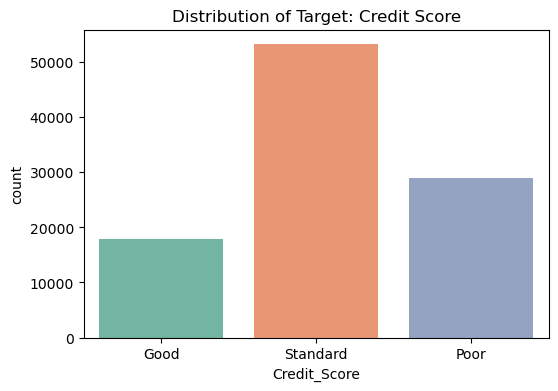

In [8]:
# 5.1 Target Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Credit_Score', hue='Credit_Score', palette='Set2', legend=False)
plt.title('Distribution of Target: Credit Score')
plt.show()


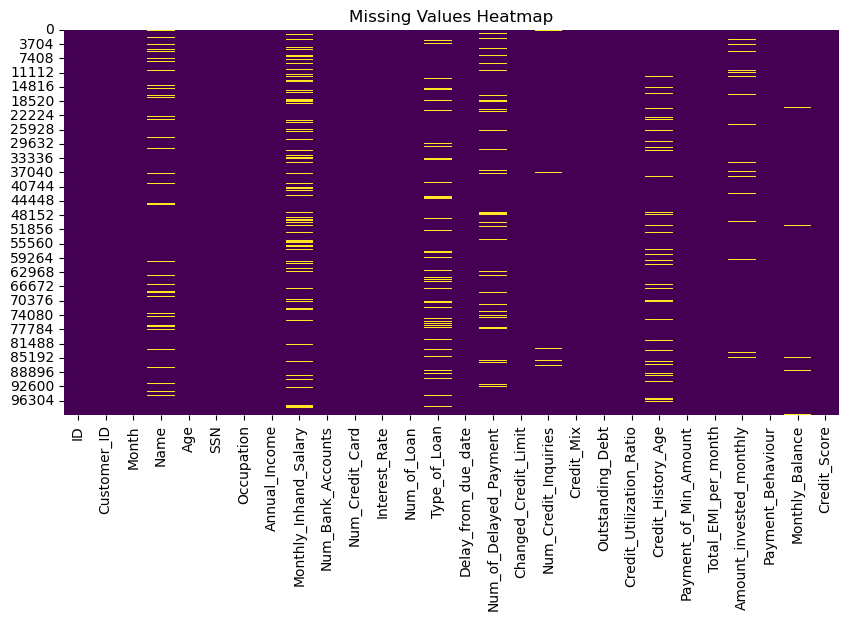

In [9]:
# 5.2 Missing Values Visual Plot
plt.figure(figsize=(10,5))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


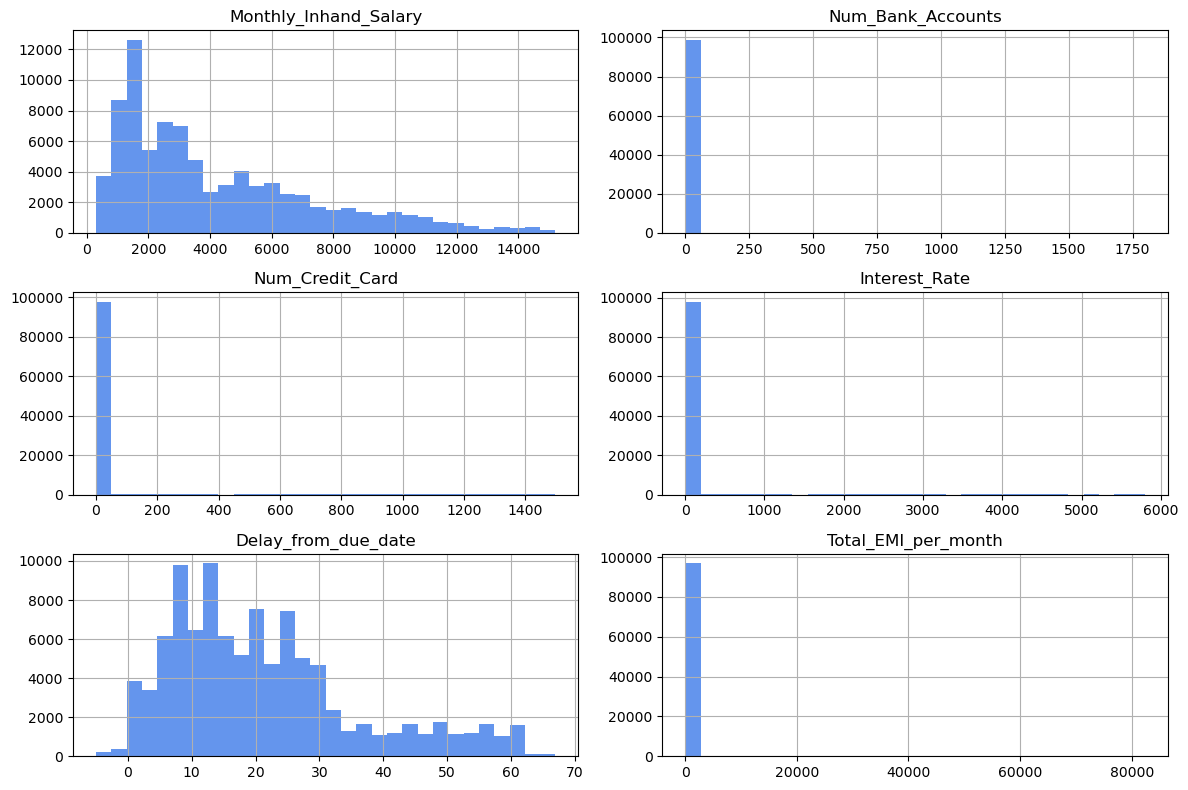

In [10]:
# 5.3 Histograms for Numerical Data
numeric_eda_cols = ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
                     'Interest_Rate', 'Delay_from_due_date', 'Total_EMI_per_month']

train_df[numeric_eda_cols].hist(figsize=(12, 8), bins=30, color='cornflowerblue')
plt.tight_layout()
plt.show()


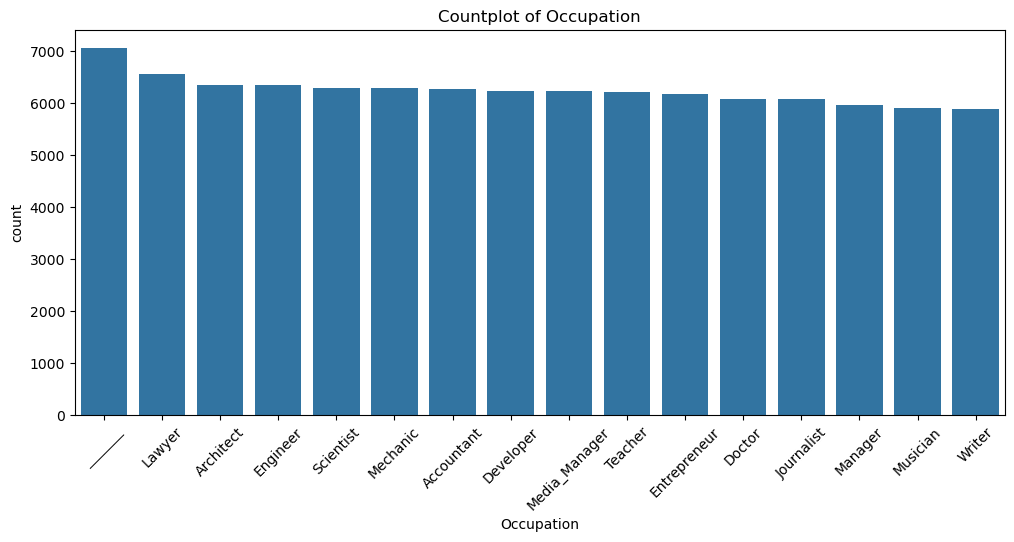

In [11]:
# 5.4 Countplot for Occupation
if 'Occupation' in train_df.columns:
    plt.figure(figsize=(12,5))
    sns.countplot(data=train_df, x='Occupation', order=train_df['Occupation'].value_counts().index)
    plt.xticks(rotation=45)
    plt.title('Countplot of Occupation')
    plt.show()


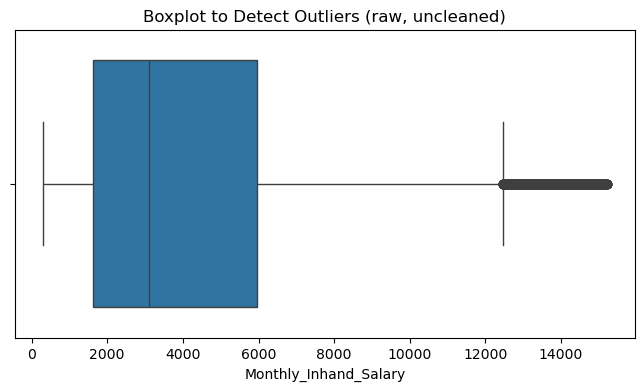

In [12]:
# 5.5 Boxplot for Outlier Visualisation (before cleaning)
plt.figure(figsize=(8,4))
sns.boxplot(data=train_df, x='Monthly_Inhand_Salary')
plt.title('Boxplot to Detect Outliers (raw, uncleaned)')
plt.show()


## 6. Data Cleaning


In [13]:
def convert_credit_age(val):
    """Robustly parse '22 Years and 1 Months' -> 265 (months), regardless of exact spacing/wording."""
    if pd.isna(val):
        return np.nan
    s = str(val)
    y = re.search(r'(\d+)\s*Years?', s)
    m = re.search(r'(\d+)\s*Months?', s)
    y = int(y.group(1)) if y else 0
    m = int(m.group(1)) if m else 0
    return y * 12 + m

for df in [train_df, test_df]:
    # 6.1 Turn underscore/garbage placeholders into real NaN, strip stray underscores from text
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace('_', np.nan)
        df[col] = df[col].astype(str).str.replace('_', '', regex=False).str.strip()
        df[col] = df[col].replace(['nan', ''], np.nan)

    # 6.2 Month kept as a numeric feature (Jan=1 ... Dec=12)
    df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month

    # 6.3 Clean numeric-as-text columns (including Monthly_Balance, which was missed before)
    dirty_cols = ['Age', 'Annual_Income', 'Outstanding_Debt', 'Num_of_Loan',
                  'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
                  'Amount_invested_monthly', 'Monthly_Balance']
    for col in dirty_cols:
        df[col] = df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 6.4 Physically impossible values -> NaN (so they get imputed properly, not fed in raw)
    df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
    df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
    df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan

    # 6.5 Robust Credit_History_Age parsing
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_age)

    # 6.6 Garbage categorical markers -> NaN
    for col in ['Occupation', 'Credit_Mix', 'Payment_Behaviour']:
        df[col] = df[col].replace(['!@9#%8', '_______'], np.nan)

    # Type_of_Loan: "no loan" is meaningful information, not missing data
    df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')




In [14]:
def fill_with_group_mode(df, groupby_col, column):
    """Fill NaN using the mode of the customer's own records across months."""
    mode_per_group = df.groupby(groupby_col)[column].transform(
        lambda x: x.mode().iat[0] if not x.mode().empty else np.nan
    )
    df[column] = df[column].fillna(mode_per_group)
    return df

group_cat_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']
group_num_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Age', 'Num_Bank_Accounts',
                   'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                   'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                   'Outstanding_Debt', 'Credit_History_Age', 'Total_EMI_per_month',
                   'Amount_invested_monthly', 'Monthly_Balance']

for df in [train_df, test_df]:
    for col in group_cat_cols:
        df = fill_with_group_mode(df, 'Customer_ID', col)
    for col in group_num_cols:
        med_by_customer = df.groupby('Customer_ID')[col].transform('median')
        df[col] = df[col].fillna(med_by_customer)

# Safety net: anything still missing (e.g. a customer with ALL months missing that field)
# falls back to the global median/mode computed from the training set.
for df in [train_df, test_df]:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(train_df[col].median())
            else:
                df[col] = df[col].fillna(train_df[col].mode()[0])

print("Missing values after cleaning (train):", train_df.isnull().sum().sum())
print("Missing values after cleaning (test):", test_df.isnull().sum().sum())


Missing values after cleaning (train): 0
Missing values after cleaning (test): 0


## 8. Outlier Handling

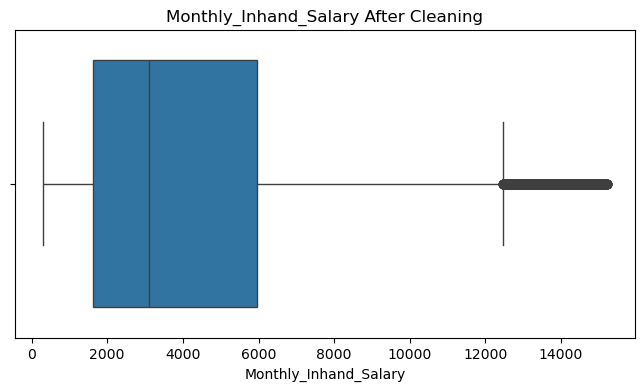

Rows kept: 100000 out of original 100000


C:\Users\Tamer\AppData\Local\Temp\ipykernel_8964\146479733.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  print("Rows kept:", len(train_df), "out of original", pd.read_csv('train.csv').shape[0])


In [15]:
# Extreme values were already converted to NaN in step 6.4 and
# filled with clean customer-level medians in step 7, so no additional row-dropping is needed — we keep
# 100% of the training data.
# Boxplot  
plt.figure(figsize=(8,4))
sns.boxplot(data=train_df, x='Monthly_Inhand_Salary')
plt.title('Monthly_Inhand_Salary After Cleaning')
plt.show()

print("Rows kept:", len(train_df), "out of original", pd.read_csv('train.csv').shape[0])


## 9. Feature Engineering


In [16]:
for df in [train_df, test_df]:
    df['Debt_to_Income']   = df['Outstanding_Debt']        / df['Annual_Income'].clip(lower=1)
    df['EMI_to_Salary']    = df['Total_EMI_per_month']     / df['Monthly_Inhand_Salary'].clip(lower=1)
    df['Savings_Rate']     = df['Amount_invested_monthly'] / df['Monthly_Inhand_Salary'].clip(lower=1)
    df['Loan_to_Accounts'] = df['Num_of_Loan']              / df['Num_Bank_Accounts'].clip(lower=1)
    df['Num_Loan_Types']   = df['Type_of_Loan'].astype(str).apply(
        lambda x: 0 if x in ['nan', 'Not Specified'] else len(x.split(','))
    )

    for c in ['Debt_to_Income', 'EMI_to_Salary', 'Savings_Rate', 'Loan_to_Accounts']:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].clip(upper=df[c].quantile(0.99))  # cap extreme ratio outliers

train_df[['Debt_to_Income', 'EMI_to_Salary', 'Savings_Rate', 'Loan_to_Accounts', 'Num_Loan_Types']].describe()


,Debt_to_Income,EMI_to_Salary,Savings_Rate,Loan_to_Accounts,Num_Loan_Types
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000
mean,5.919001e-02,0.378481,0.203872,0.781977,3.51880
std,8.277079e-02,2.253893,0.830926,0.731856,2.46371
min,4.086800e-07,0.000000,0.000000,0.000000,0.00000
25%,9.260348e-03,0.012597,0.026477,0.333333,2.00000
50%,2.780103e-02,0.025257,0.047163,0.666667,3.00000
75%,6.908294e-02,0.042732,0.079582,1.000000,5.00000
max,4.449506e-01,18.621338,6.365862,4.000000,9.00000


## 10. Correlation Heatmap 
### after cleaning + feature engineering

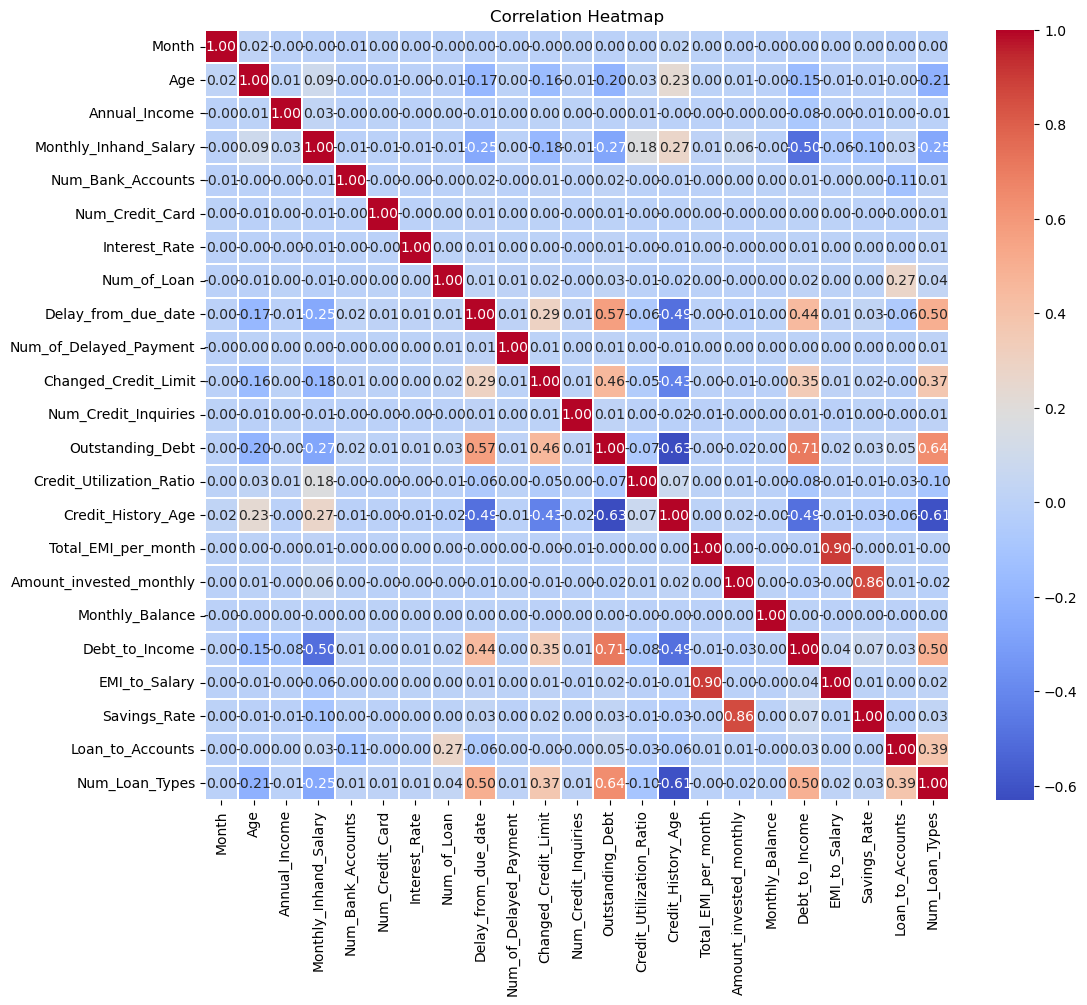

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(train_df.corr(numeric_only=True),fmt='.2f', annot=True , cmap='coolwarm', linewidths=0.3)
plt.title('Correlation Heatmap')
plt.show()


## 11. Categorical Encoding

In [18]:
categorical_cols = ['Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Mix']
label_encoders = {}

In [19]:
for col in categorical_cols:
    if col in train_df.columns:
        print(f"--- Value Counts for {col} ---")
        print(train_df[col].value_counts())

--- Value Counts for Occupation ---
Occupation
Lawyer          7096
Engineer        6864
Architect       6824
Mechanic        6776
Scientist       6744
Accountant      6744
Developer       6720
MediaManager    6720
Teacher         6672
Entrepreneur    6648
Doctor          6568
Journalist      6536
Manager         6432
Musician        6352
Writer          6304
Name: count, dtype: int64
--- Value Counts for Payment_of_Min_Amount ---
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64
--- Value Counts for Payment_Behaviour ---
Payment_Behaviour
LowspentSmallvaluepayments      27767
HighspentMediumvaluepayments    19366
HighspentLargevaluepayments     15348
LowspentMediumvaluepayments     14621
HighspentSmallvaluepayments     11980
LowspentLargevaluepayments      10918
Name: count, dtype: int64
--- Value Counts for Credit_Mix ---
Credit_Mix
Standard    45848
Good        30384
Bad         23768
Name: count, dtype: int64


In [20]:
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    # Map any category in test.csv that the encoder never saw in training to a known class,
    # instead of crashing on transform()
    test_df[col] = test_df[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le

# Encode the target
target_le = LabelEncoder()
train_df['Credit_Score'] = target_le.fit_transform(train_df['Credit_Score'])
print("Target classes:", list(target_le.classes_))


Target classes: ['Good', 'Poor', 'Standard']


## 12. Feature Selection & Train/Validation Split

In [21]:
# Drop identifier/structural columns only
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']
features = [c for c in train_df.columns if c not in drop_cols + ['Credit_Score']]

X = train_df[features]
y = train_df['Credit_Score']

test_ids = test_df['ID']
X_test_final = test_df[features]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling 
# only needed for Logistic Regression 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train shape:", X_train.shape, " Validation shape:", X_val.shape)


Train shape: (80000, 27)  Validation shape: (20000, 27)


## 13. Model Training & Evaluation

### 13.1 Logistic Regression 

In [22]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_val_scaled)

print("--- Logistic Regression Evaluation ---")
print(classification_report(y_val, lr_preds, target_names=target_le.classes_))


--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

        Good       0.52      0.48      0.50      3566
        Poor       0.63      0.45      0.53      5799
    Standard       0.63      0.75      0.68     10635

    accuracy                           0.61     20000
   macro avg       0.59      0.56      0.57     20000
weighted avg       0.61      0.61      0.61     20000



### 13.2 Decision Tree Classifier

In [23]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_val)

print("--- Decision Tree Evaluation ---")
print(classification_report(y_val, dt_preds, target_names=target_le.classes_))


--- Decision Tree Evaluation ---
              precision    recall  f1-score   support

        Good       0.59      0.69      0.64      3566
        Poor       0.75      0.64      0.69      5799
    Standard       0.75      0.77      0.76     10635

    accuracy                           0.72     20000
   macro avg       0.70      0.70      0.70     20000
weighted avg       0.72      0.72      0.72     20000



### 13.3 Random Forest Classifier 


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)
rf_probs = rf_model.predict_proba(X_val)

print("--- Random Forest Evaluation ---")
print(classification_report(y_val, rf_preds, target_names=target_le.classes_))


--- Random Forest Evaluation ---
              precision    recall  f1-score   support

        Good       0.78      0.80      0.79      3566
        Poor       0.81      0.84      0.82      5799
    Standard       0.85      0.82      0.84     10635

    accuracy                           0.83     20000
   macro avg       0.81      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000



### 13.4 HistGradientBoosting Classifier 



In [25]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.1,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    random_state=42
)
hgb_model.fit(X_train, y_train)
hgb_preds = hgb_model.predict(X_val)
hgb_probs = hgb_model.predict_proba(X_val)

print("--- HistGradientBoosting Evaluation ---")
print(classification_report(y_val, hgb_preds, target_names=target_le.classes_))


--- HistGradientBoosting Evaluation ---
              precision    recall  f1-score   support

        Good       0.78      0.78      0.78      3566
        Poor       0.80      0.81      0.80      5799
    Standard       0.83      0.82      0.83     10635

    accuracy                           0.81     20000
   macro avg       0.80      0.81      0.80     20000
weighted avg       0.81      0.81      0.81     20000



## 14. Model Comparison Matrix

In [26]:
models_stats = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest',
              'HistGradientBoosting'],
    'Accuracy': [
        accuracy_score(y_val, lr_preds),
        accuracy_score(y_val, dt_preds),
        accuracy_score(y_val, rf_preds),
        accuracy_score(y_val, hgb_preds)
        
    ],
    'Precision (Macro)': [
        precision_score(y_val, lr_preds, average='macro'),
        precision_score(y_val, dt_preds, average='macro'),
        precision_score(y_val, rf_preds, average='macro'),
        precision_score(y_val, hgb_preds, average='macro')
        
    ],
    'Recall (Macro)': [
        recall_score(y_val, lr_preds, average='macro'),
        recall_score(y_val, dt_preds, average='macro'),
        recall_score(y_val, rf_preds, average='macro'),
        recall_score(y_val, hgb_preds, average='macro')
        
    ],
    'F1-Score (Macro)': [
        f1_score(y_val, lr_preds, average='macro'),
        f1_score(y_val, dt_preds, average='macro'),
        f1_score(y_val, rf_preds, average='macro'),
        f1_score(y_val, hgb_preds, average='macro')
    ]
}

comparison_df = pd.DataFrame(models_stats).set_index('Model')
comparison_df


,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
Model,,,,
Logistic Regression,0.61360,0.594384,0.559354,0.569913
Decision Tree,0.71940,0.698668,0.700670,0.697148
Random Forest,0.82505,0.813560,0.822022,0.817551
HistGradientBoosting,0.81110,0.800985,0.805345,0.803103


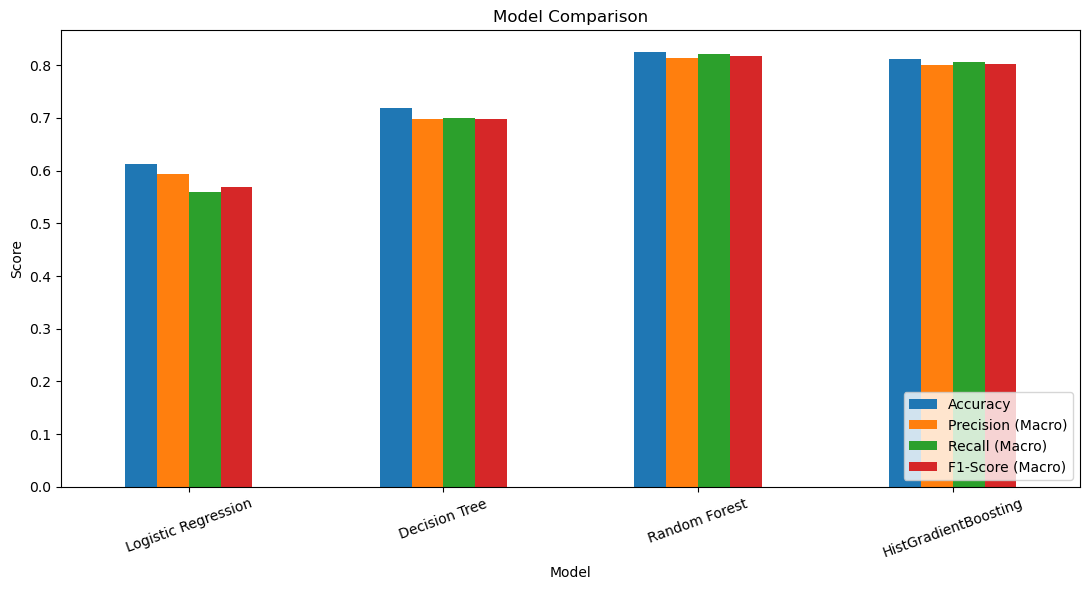

In [27]:
comparison_df.plot(kind='bar', figsize=(11, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 15. Confusion Matrices

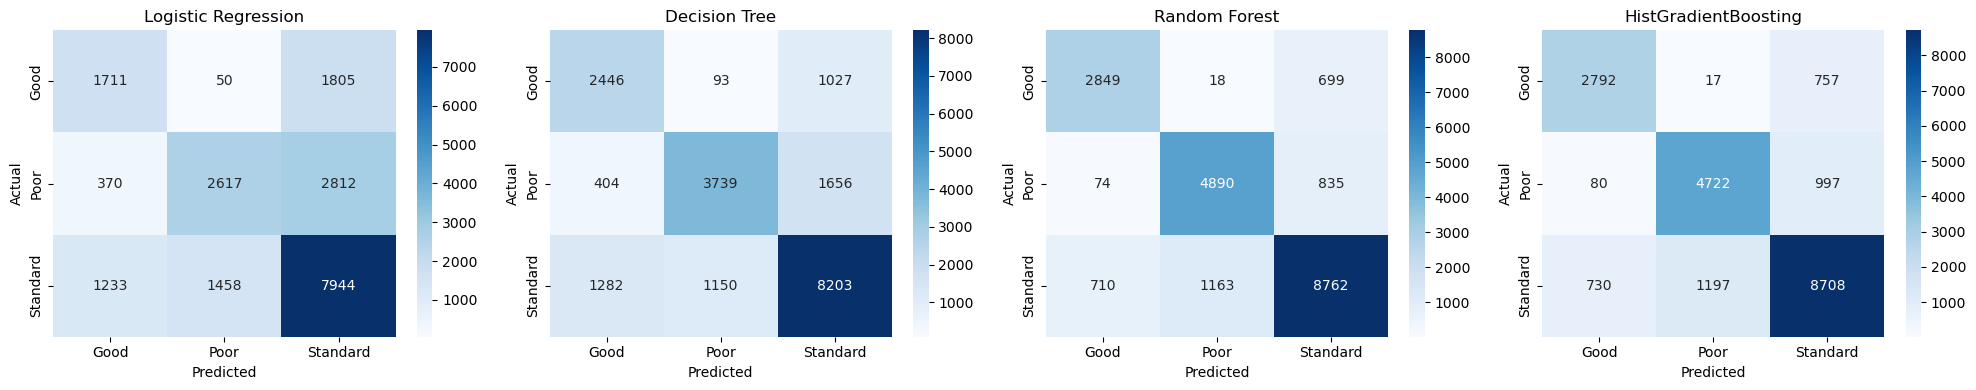

In [28]:
target_names = list(target_le.classes_)

preds_dict = {'Logistic Regression': lr_preds, 'Decision Tree': dt_preds,
              'Random Forest': rf_preds, 'HistGradientBoosting': hgb_preds}

fig, axes = plt.subplots(1, len(preds_dict), figsize=(5*len(preds_dict), 4))
for ax, (name, pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 16. Feature Importance 

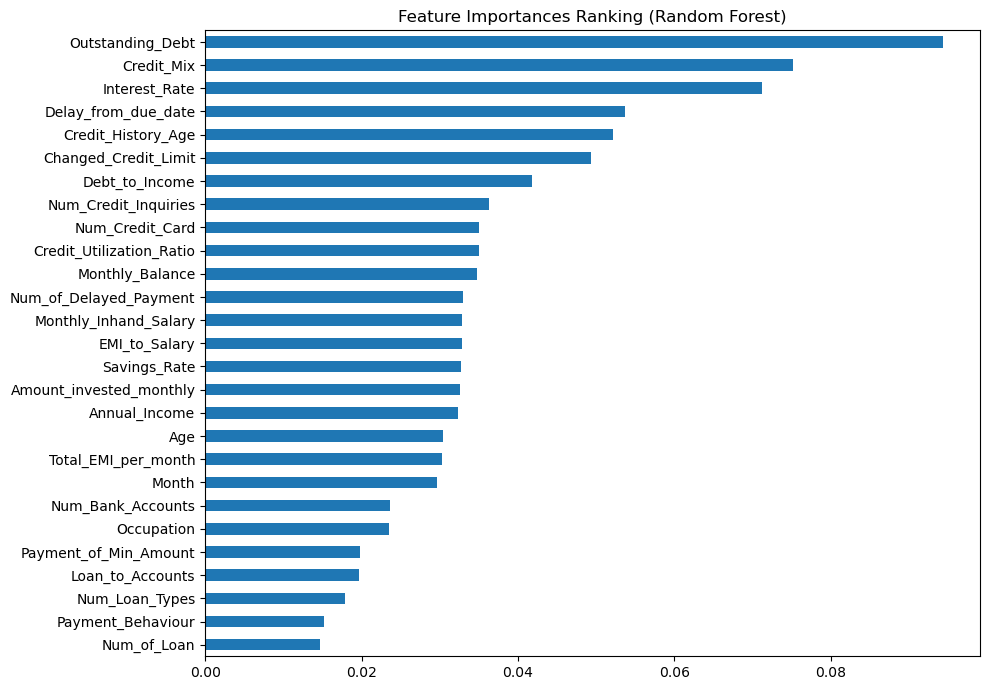

Outstanding_Debt            0.094393
Credit_Mix                  0.075133
Interest_Rate               0.071241
Delay_from_due_date         0.053746
Credit_History_Age          0.052120
Changed_Credit_Limit        0.049291
Debt_to_Income              0.041840
Num_Credit_Inquiries        0.036253
Num_Credit_Card             0.035073
Credit_Utilization_Ratio    0.035023
Monthly_Balance             0.034821
Num_of_Delayed_Payment      0.032953
Monthly_Inhand_Salary       0.032849
EMI_to_Salary               0.032821
Savings_Rate                0.032737
dtype: float64

In [29]:
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,7))
feat_importances.plot(kind='barh')
plt.title('Feature Importances Ranking (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feat_importances.head(15)


## 17. Prediction on test.csv & Export Results

In [30]:
test_probs = 0.7 * rf_model.predict_proba(X_test_final) + 0.3 * hgb_model.predict_proba(X_test_final)
test_predictions = np.argmax(test_probs, axis=1)
test_predictions_labels = target_le.inverse_transform(test_predictions)

submission_df = pd.DataFrame({
    'ID': test_ids,
    'Predicted_Credit_Score': test_predictions_labels
})

submission_df.to_csv('test_predictions.csv', index=False)
print("Success! Predictions saved to 'test_predictions.csv'.")
submission_df.head()


Success! Predictions saved to 'test_predictions.csv'.


,ID,Predicted_Credit_Score
0,0x160a,Good
1,0x160b,Good
2,0x160c,Good
3,0x160d,Good
4,0x1616,Good


## Finish the Project